In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import warnings
warnings.filterwarnings("ignore")
import sys
sys.path.append('/home/future_commodity')
import pandas as pd
import numpy as np
np.seterr(all='ignore')
import lightgbm as lgb
from pathlib import Path
import os
from typing import List, Tuple
import function_future.pre_train as pt
import function_future.train_model as tm
import function_future.FactorFilter as FF
import function_future.backtest_v3 as bv
import function_future.DataLoader as DL, function_future.date_selection as DS
import function_future.trading_visualization as TV
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from joblib import Parallel, delayed
import re


In [3]:
symbol = 'EG'
train_label = 5
train_end_date = '2025-01-01'

folder_name = f'{symbol}_pred{train_label}_{train_end_date}_v0'

rtn_mul = 1
config_loader = DL.InstrumentConfig()
config_loader.get_instrument_config(symbol)

{'symbol': 'EG',
 'contract_multiplier': 10,
 'price_tick': 1,
 'margin_rate': 0.07,
 'fee': 3,
 'fee_way': 'number',
 'fee_comment': '无',
 'trading_hours': ['09:00-11:30', '13:30-15:00', '21:00-23:00'],
 'light': 1,
 'night': 1,
 'exchange': 'dce',
 'name': '乙二醇'}

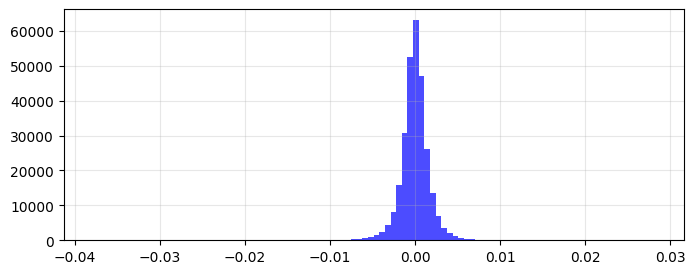


Fold 1/5
Fold 1 验证集日期范围: 2021-02-02 09:11:00 至 2021-11-18 13:34:00
Fold 1 训练集样本数: 226609, 验证集样本数: 56653
Training until validation scores don't improve for 500 rounds
[100]	valid_0's l2: 0.99122
[200]	valid_0's l2: 0.991259
[300]	valid_0's l2: 0.991284
[400]	valid_0's l2: 0.991326
[500]	valid_0's l2: 0.99137
Early stopping, best iteration is:
[5]	valid_0's l2: 0.991205


<Figure size 1000x600 with 0 Axes>

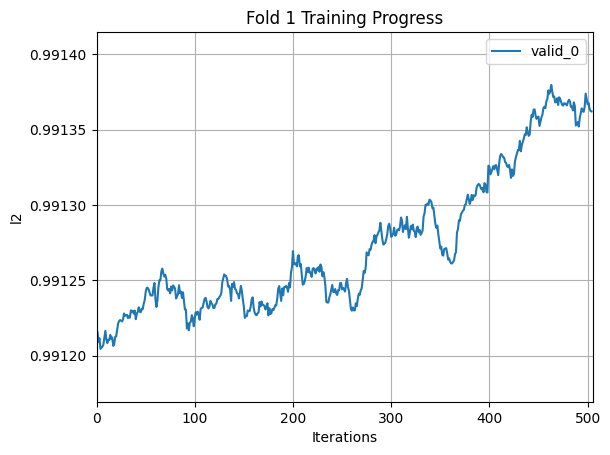

valid ic: 0.0074189751400540235
模型最佳迭代次数 = 5

Fold 2/5
Fold 2 验证集日期范围: 2021-11-18 13:35:00 至 2022-08-29 09:20:00
Fold 2 训练集样本数: 226609, 验证集样本数: 56653
Training until validation scores don't improve for 500 rounds
[100]	valid_0's l2: 0.99132
[200]	valid_0's l2: 0.991275
[300]	valid_0's l2: 0.991241
[400]	valid_0's l2: 0.991224
[500]	valid_0's l2: 0.99124
[600]	valid_0's l2: 0.991249
[700]	valid_0's l2: 0.991241
[800]	valid_0's l2: 0.991316
[900]	valid_0's l2: 0.99133
Early stopping, best iteration is:
[418]	valid_0's l2: 0.991212


<Figure size 1000x600 with 0 Axes>

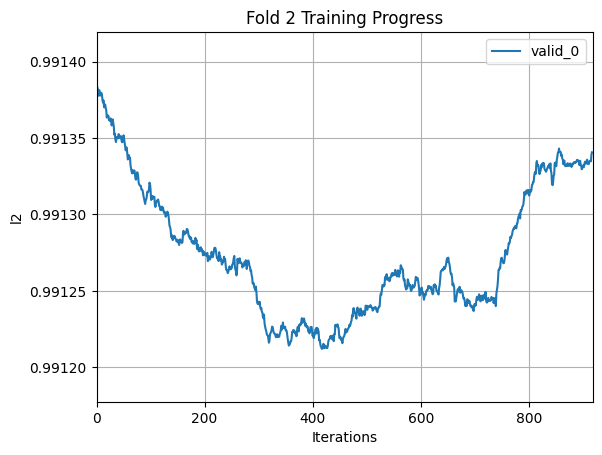

valid ic: 0.013602206261611002
模型最佳迭代次数 = 418

Fold 3/5
Fold 3 验证集日期范围: 2022-08-29 09:21:00 至 2023-06-13 21:46:00
Fold 3 训练集样本数: 226610, 验证集样本数: 56652
Training until validation scores don't improve for 500 rounds
[100]	valid_0's l2: 0.991299
[200]	valid_0's l2: 0.991291
[300]	valid_0's l2: 0.991289
[400]	valid_0's l2: 0.991282
[500]	valid_0's l2: 0.991273
[600]	valid_0's l2: 0.991274
[700]	valid_0's l2: 0.991269
[800]	valid_0's l2: 0.991255
[900]	valid_0's l2: 0.991254
[1000]	valid_0's l2: 0.991256
[1100]	valid_0's l2: 0.991251
[1200]	valid_0's l2: 0.991256
[1300]	valid_0's l2: 0.991265
[1400]	valid_0's l2: 0.991261
[1500]	valid_0's l2: 0.99127
[1600]	valid_0's l2: 0.991268
Early stopping, best iteration is:
[1145]	valid_0's l2: 0.991246


<Figure size 1000x600 with 0 Axes>

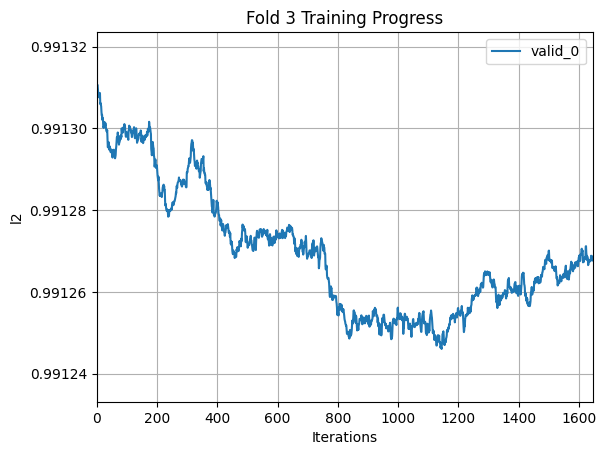

valid ic: 0.010910488850800634
模型最佳迭代次数 = 1145

Fold 4/5
Fold 4 验证集日期范围: 2023-06-13 21:47:00 至 2024-03-25 09:31:00
Fold 4 训练集样本数: 226610, 验证集样本数: 56652
Training until validation scores don't improve for 500 rounds
[100]	valid_0's l2: 0.991387
[200]	valid_0's l2: 0.991386
[300]	valid_0's l2: 0.991375
[400]	valid_0's l2: 0.991381
[500]	valid_0's l2: 0.991383
[600]	valid_0's l2: 0.991381
[700]	valid_0's l2: 0.991381
[800]	valid_0's l2: 0.991385
[900]	valid_0's l2: 0.991401
[1000]	valid_0's l2: 0.991405
[1100]	valid_0's l2: 0.991416
Early stopping, best iteration is:
[650]	valid_0's l2: 0.991369


<Figure size 1000x600 with 0 Axes>

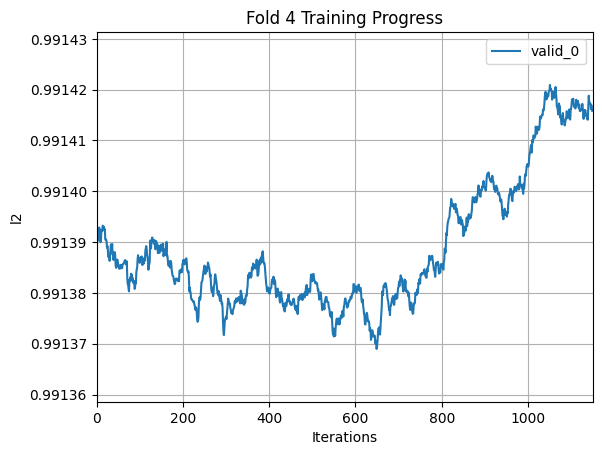

valid ic: 0.005160138907991691
模型最佳迭代次数 = 650

Fold 5/5
Fold 5 验证集日期范围: 2024-03-25 09:32:00 至 2024-12-31 14:49:00
Fold 5 训练集样本数: 226610, 验证集样本数: 56652
Training until validation scores don't improve for 500 rounds
[100]	valid_0's l2: 0.991522
[200]	valid_0's l2: 0.991552
[300]	valid_0's l2: 0.99156
[400]	valid_0's l2: 0.991567
[500]	valid_0's l2: 0.991564
Early stopping, best iteration is:
[21]	valid_0's l2: 0.991499


<Figure size 1000x600 with 0 Axes>

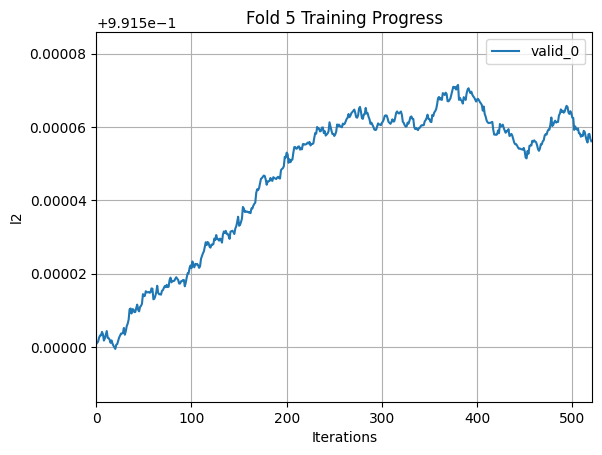

valid ic: 0.003504717752400308
模型最佳迭代次数 = 21
特征重要性已保存到 /mnt/Data/writable/liaoyuyang/factor_eval_commodity/2025-01-01/importance/2025-01-01_EG_5_feature_importance_reg.csv
特征相关系数表已保存到 /mnt/Data/writable/liaoyuyang/factor_eval_commodity/2025-01-01/correlation/2025-01-01_EG_5_feature_corr.csv
因子组别表已保存到 /mnt/Data/writable/liaoyuyang/factor_eval_commodity/2025-01-01/group/2025-01-01_EG_5_feature_group.csv
最后两列 Index(['pred_ret', 'hour'], dtype='object')


In [4]:
fac_df = pd.read_feather(f'/mnt/Data/writable/liaoyuyang/factor/{symbol}/all_fac/all_factor.feather').set_index(['datetime']).loc[:train_end_date]
fac_df = config_loader.df_cut_time(fac_df, config_loader.get_instrument_config(symbol)['trading_hours'], 10)

exclude_factors = [
        'datetime', 'instrument',
        ]

factor_col = [x for x in fac_df.columns if x not in exclude_factors]

main_fac_piv = fac_df[factor_col]
rtn_df = pd.read_csv(f'/mnt/Data/writable/liaoyuyang/data/1min/active/main_{symbol}.csv', index_col=0, parse_dates=['ts']).set_index('ts').reindex(index=fac_df.index)
main_fac_piv['pred_ret'] = rtn_df[f'rtn_{train_label}']
main_fac_piv = main_fac_piv.replace([np.inf, -np.inf], np.nan)
main_fac_piv['hour'] = main_fac_piv.index.hour

main_fac_piv['pred_ret'].hist(bins=100, figsize=(8, 3), alpha=0.7, color='blue')
plt.grid(True, alpha=0.3)
plt.show()

pretrainer = pt.Pretrainer(symbol, main_fac_piv, train_end_date, train_label=train_label)

importance = pretrainer.run_full_pretraining(type_lgb = 'reg')

In [5]:
factor_info = pd.read_csv(f'/mnt/Data/writable/liaoyuyang/factor_eval_commodity/{train_end_date}/{symbol}_single_factor_eval_{train_label}.csv', index_col=0)
importance_df = pd.read_csv(f'/mnt/Data/writable/liaoyuyang/factor_eval_commodity/{train_end_date}/importance/{train_end_date}_{symbol}_{train_label}_feature_importance_reg.csv')
corr_df = pd.read_csv(f'/mnt/Data/writable/liaoyuyang/factor_eval_commodity/{train_end_date}/correlation/{train_end_date}_{symbol}_{train_label}_feature_corr.csv', index_col=0)
group_df = pd.read_csv(f'/mnt/Data/writable/liaoyuyang/factor_eval_commodity/{train_end_date}/group/{train_end_date}_{symbol}_{train_label}_feature_group.csv')
factor_to_choose = main_fac_piv.columns[:-1]

factor_filter = FF.FactorFilter(importance_df, corr_df, group_df, factor_info, factor_to_choose)
print([x for x in factor_filter.factor_to_choose if x not in factor_info.index])
params = {
    "info_select_params": {"nan_rate": 0.8, "mode_rate": 0.9},
    "importance_select_by_group_params" : {"cut_num_1": 300, "cut_num_2":200, "same_name_cut": 5}, 
    "corr_select_params": {"feature_num_limit": 300, "corr_limit": 0.9}, 
    "sp_select": {"th":0.5},
    "day_cut": {"num_limit":5},
    "exclude_factors": [
            'datetime', 'instrument',
            'JC1D', 'ZCpriceinterval', 'ptvol5',
            'JC2H'
            ]
}
factor_filter.run_selection(**params)

lst1 = [x for x in factor_filter.factor_to_choose if x.startswith('FAC')]
lst2 = [x for x in factor_filter.factor_to_choose if x.startswith('STK')]
lst3 = [x for x in factor_filter.factor_to_choose if re.match(r'^(_RU|_BR|_NR|_L|_TA|_PF|_V|_EG|_MA|_PP|_EB|_UR|_SA|_SH|_PX|_PR|RU_|BR_|NR_|L_|TA_|PF_|V_|EG_|MA_|PP_|EB_|UR_|SA_|SH_|PX_|PR_)', x)]
lst4 = [x for x in factor_filter.factor_to_choose if x not in lst1+lst2+lst3]
len(lst1), len(lst2), len(lst3), len(lst4)

['FAC_Depth_Reversal_upmean', 'pred_ret']
特征分布性过滤：
筛选之前因子数量：1927， 筛选之后因子数量：1851

特征重要性过滤： 300 200 	待筛因子个数 1851
无向因子有效个数： 938 有向因子有效个数： 824
  选择有向特征 213 个，重要性范围: 491.00 - 10.00
  选择无向特征 137 个，重要性范围: 569.00 - 21.00

单因子sharpe过滤： 0.5 sp范围-6.4102 ~ 5.0294   待筛因子个数 350

特征相关性性过滤： 300     待筛因子个数 280
  选择特征 218 个, 特征最大相关性0.897095180806142

已挑选日频开盘因子数量： 5 ['day_first4redcorr', 'day_jump', 'day_first4greencorr', 'day_first10rev', 'day_first10colarrate']

保留日频开盘因子数量： 5 ['day_first4redcorr', 'day_jump', 'day_first4greencorr', 'day_first10rev', 'day_first10colarrate']

排除指定因子后，剩余特征 216 个


(132, 0, 59, 25)

正在从 /mnt/Data/writable/liaoyuyang/factor/EG/all_fac/all_factor.feather 加载数据...
训练数据加载完成，形状: (283262, 1931)
训练集时间范围: 2021-02-02 09:11:00 至 2024-12-31 14:49:00
[200]	valid_0's rmse: 0.995913
[400]	valid_0's rmse: 0.9963


<Figure size 1000x600 with 0 Axes>

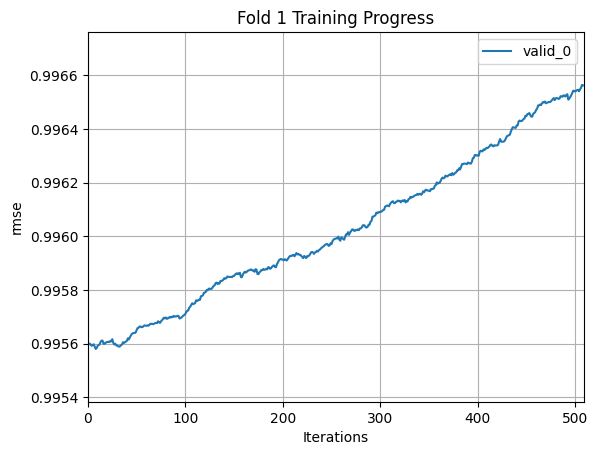

{'train_rmse': np.float64(0.9998569730523216), 'val_rmse': np.float64(0.9999852315703797), 'best_iteration': 9}
test_corr: 0.0088
[200]	valid_0's rmse: 0.99556
[400]	valid_0's rmse: 0.995511
[600]	valid_0's rmse: 0.995654
[800]	valid_0's rmse: 0.995758


<Figure size 1000x600 with 0 Axes>

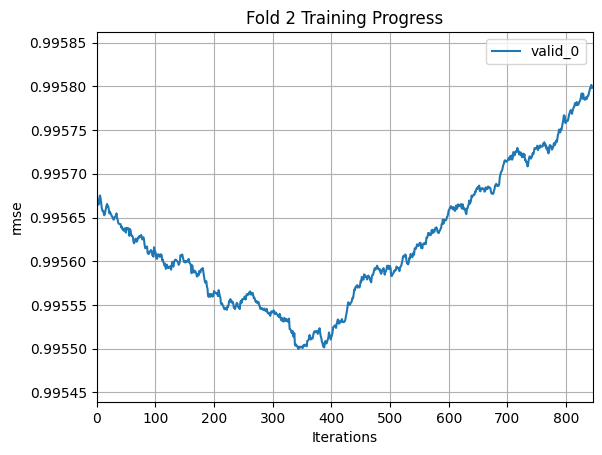

{'train_rmse': np.float64(0.9934163495226691), 'val_rmse': np.float64(0.9998109027265124), 'best_iteration': 345}
test_corr: 0.0004
[200]	valid_0's rmse: 0.995621
[400]	valid_0's rmse: 0.995623
[600]	valid_0's rmse: 0.995638


<Figure size 1000x600 with 0 Axes>

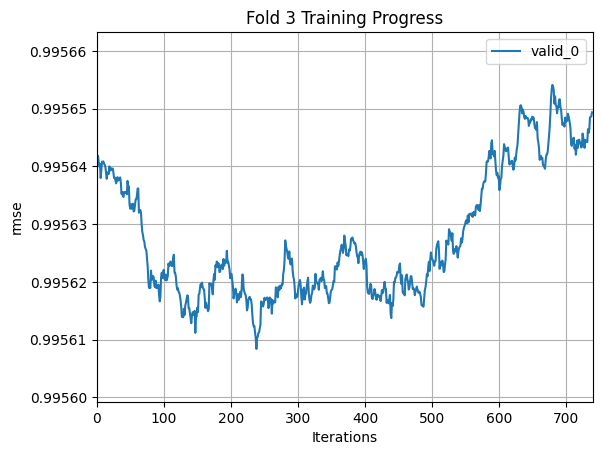

{'train_rmse': np.float64(0.9957229969606178), 'val_rmse': np.float64(0.9999776127251605), 'best_iteration': 239}
test_corr: 0.0019
[200]	valid_0's rmse: 0.99566
[400]	valid_0's rmse: 0.995684
[600]	valid_0's rmse: 0.995725


<Figure size 1000x600 with 0 Axes>

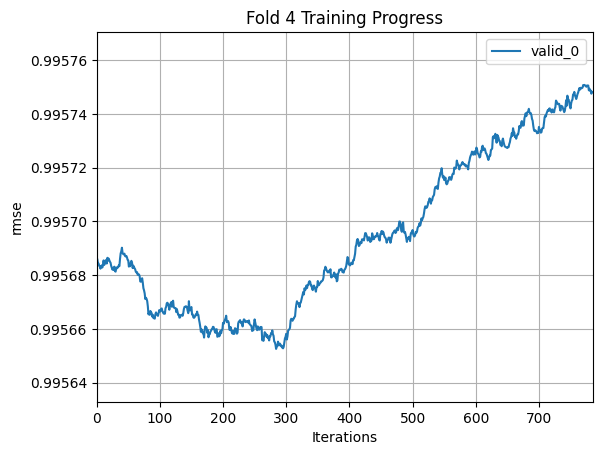

{'train_rmse': np.float64(0.9950750270871034), 'val_rmse': np.float64(0.999965614878336), 'best_iteration': 285}
test_corr: 0.0011
[200]	valid_0's rmse: 0.995747
[400]	valid_0's rmse: 0.99572
[600]	valid_0's rmse: 0.995652
[800]	valid_0's rmse: 0.995625
[1000]	valid_0's rmse: 0.995569
[1200]	valid_0's rmse: 0.995517
[1400]	valid_0's rmse: 0.9955
[1600]	valid_0's rmse: 0.995495
[1800]	valid_0's rmse: 0.995486
[2000]	valid_0's rmse: 0.995492
[2200]	valid_0's rmse: 0.995482
[2400]	valid_0's rmse: 0.995499


<Figure size 1000x600 with 0 Axes>

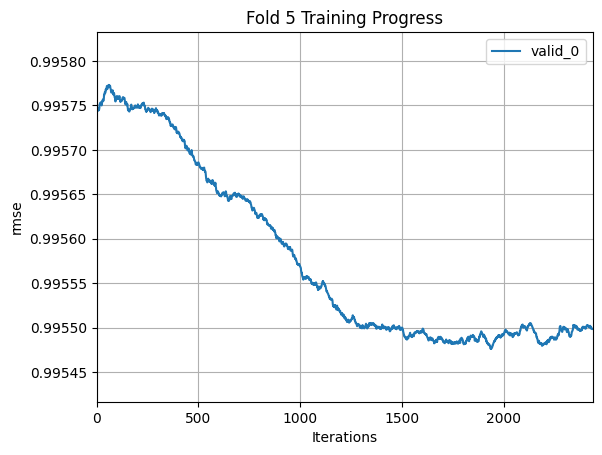

{'train_rmse': np.float64(0.9767126844146361), 'val_rmse': np.float64(0.999737483934148), 'best_iteration': 1937}
test_corr: 0.0017


In [6]:
analyzer = tm.TimeSeriesAnalyzer(
    symbol = symbol,
    factor_col = factor_filter.factor_to_choose,
    train_end_date = train_end_date,
    config_loader = config_loader
)
analyzer.load_and_prepare_data(log_rtn=True, set_category_col=['hour'], label_col=f'rtn_{train_label}', cut=True)
trainer = tm.LGBMTrainer(analyzer)
_ = trainer.train_kfold_v0(custom_params={'verbose':-1}, model_folder_name=folder_name, plot_train=True, n_splits=5)

In [7]:
config = bv.load_config(r"/mnt/Data/writable/liaoyuyang/backtest/backtest_config.json")
config['MODEL_DIR'] = Path(config['MODEL_DIR']) / str(folder_name)
config

{'MODEL_DIR': PosixPath('/mnt/Data/writable/liaoyuyang/model/lightgbm/KFoldModel/models/EG_pred5_2025-01-01_v0'),
 'OUTPUT_DIR': '/mnt/Data/writable/liaoyuyang/backtest/results',
 'pic_dir': '/mnt/Data/writable/liaoyuyang/backtest/pic',
 'feature_dir': '/mnt/Data/writable/liaoyuyang/backtest/data/features',
 'pred_label_dir': '/mnt/Data/writable/liaoyuyang/backtest/data/predictions',
 'merged_output_dir': '/mnt/Data/writable/liaoyuyang/backtest/data/merged',
 'start_date': '20180101',
 'end_date': '20260101',
 'ts_col': 'datetime',
 'instrument_col': 'instrument',
 'target_col': 'pred_ret',
 'holding_price_col': 'close',
 'trading_price_col': 'tick6t60avg',
 'pos_col': 'pos',
 'category_col': ['hour'],
 'factor_col': 'factor',
 'filter_dict': {'exclude_night': True},
 'auto_create_dirs': True}

In [8]:
bt = bv.ModelBacktester(train_end_date, config)
bt.load_config(symbol)
bt.window_end = '2027-01-01'
bt.money = 2_000_000 
bt.fee = 0

bt.load_factor(symbol, end_date=bt.window_end)
bt.load_mktdata(symbol, end_date=bt.window_end)
bt.load_models()
bt.generate_predictions()
pred = bt.combine_models('best_iteration_log_weighted', avg=True)

In [9]:
merged_data = bt.backtest(th1=0.8, th2=0.5, save=False, open_drop=True, holding_bars=10,
                           day=5*345, model_name='best_iteration_log_weighted', v=2
                        )

trading_hours ['09:00-11:30', '13:30-15:00', '21:00-23:00']


  0%|          | 0/78931 [00:00<?, ?it/s]

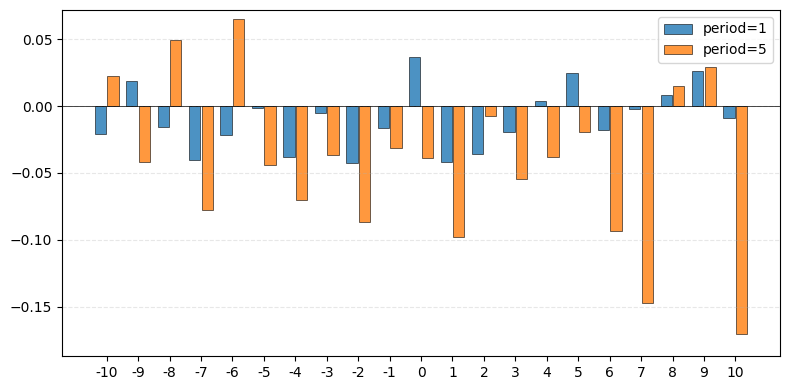

In [10]:
fig = bv.plot_group_bar(merged_data, periods=[1,5], trading_hours=["09:00-11:30", "13:30-15:00", "21:00-01:00"], g=21)

In [11]:
bv.analyze_pos_distribution(merged_data)

,统计值
多头(+1) 数量,20439
空头(-1) 数量,25381
空仓(0) 数量,33113
多头占比,25.89%
空头占比,32.16%
空仓占比,41.95%
交易日数量,232
总收益(非年化%),1.25
总交易次数（开平算一次）,5089
每笔收益(%%),0.02


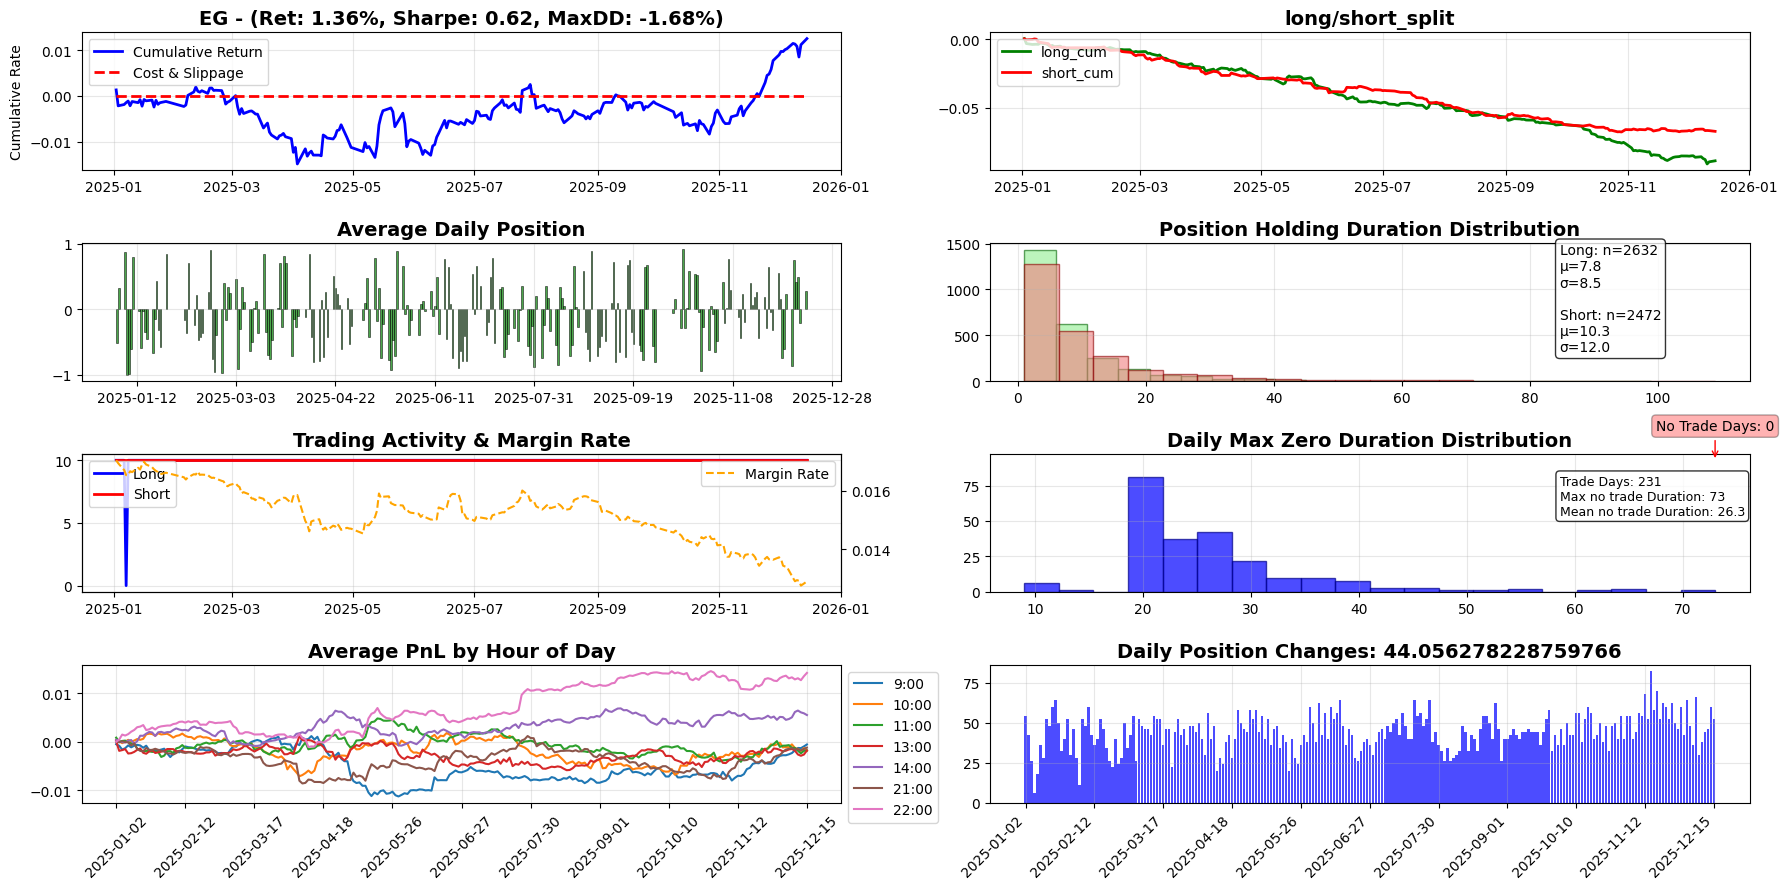

In [12]:
fig = bv.plot_eval(symbol, merged_data, "无")

In [13]:
tvp = TV.TradingVisualizationPager(symbol=symbol, data = merged_data, skip_weekends=True)
tvp.run()

Output()

✅ 交易可视化工具已启动
📈 品种: EG
📅 总交易日数: 231
📊 总数据点: 83853
🎯 使用导航按钮或输入页码进行浏览


In [14]:
bv.plot_yearly_eval(merged_data)